# Лабораторная работа №1
## Использование нейронных сетей прямого распространения для решения задач классификации

**Вариант 20**  
**Датасет:** Car Evaluation (классификация класса автомобиля)  
**Дополнительное исследование:** Сравнение оптимизаторов AdamW, Adam, Adagrad при фиксированных learning rate и batch size

## 1. Импорт библиотек

Перед тем как загрузить данные, нужно импортировать библиотеки, которые будем использовать: `torch` и `torch.nn` (для построения и обучения нейронных сетей), `torch.optim` (для оптимизаторов), `numpy` (для работы с массивами данных), `pandas` (для загрузки и анализа датасета), `matplotlib.pyplot` (библиотека для визуализации данных), `seaborn` (для построения тепловой карты и матрицы ошибок), а также модули из `sklearn` для предобработки данных и оценки модели.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

torch.manual_seed(42)
np.random.seed(42)

Датасет Car Evaluation содержит информацию об автомобилях с шестью категориальными признаками: цена покупки (buying), стоимость обслуживания (maint), количество дверей (doors), вместимость пассажиров (persons), размер багажника (lug_boot) и уровень безопасности (safety). Целевая переменная (class) принимала четыре значения: unacc (неприемлемый), acc (приемлемый), good (хороший) и vgood (очень хороший). Все признаки являлись категориальными, поэтому требовалось числовое кодирование. Файл не содержал заголовков, поэтому названия столбцов были заданы вручную при загрузке.


In [23]:
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
data = pd.read_csv('https://drive.google.com/uc?export=download&id=1e3EBkO8L3zfoSdrCCLsl9ovh34ADLaSL', names=columns)
data.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Для вывода информации о данных используется метод `.info()`. С помощью него можно просмотреть типы данных в столбцах и количество непустых значений.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


## 3. Предобработка данных

Далее проверяется наличие пропущенных значений с помощью метода `.isna()` и функции `.sum()`.

In [24]:
print(data.isna().sum())

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


Пропущенных значений не обнаружено — датасет полный, дополнительная обработка пропусков не требуется.

Далее идёт поиск явных дубликатов в данных с помощью метода `.duplicated()` и функции `.sum()`.

In [5]:
print('Количество явных дубликатов:', data.duplicated().sum())

Количество явных дубликатов: 0


Явных дубликатов не найдено.

Поиск неявных дубликатов с помощью вывода уникальных значений столбцов.

In [6]:
for col in data.columns:
    print(f'{col}: {list(data[col].unique())}')

buying: ['vhigh', 'high', 'med', 'low']
maint: ['vhigh', 'high', 'med', 'low']
doors: ['2', '3', '4', '5more']
persons: ['2', '4', 'more']
lug_boot: ['small', 'med', 'big']
safety: ['low', 'med', 'high']
class: ['unacc', 'acc', 'vgood', 'good']


Неявных дубликатов не обнаружено — значения в каждом столбце корректны.

Далее анализируется распределение целевой переменной. Это важно, так как несбалансированность классов может негативно повлиять на качество обучения модели.

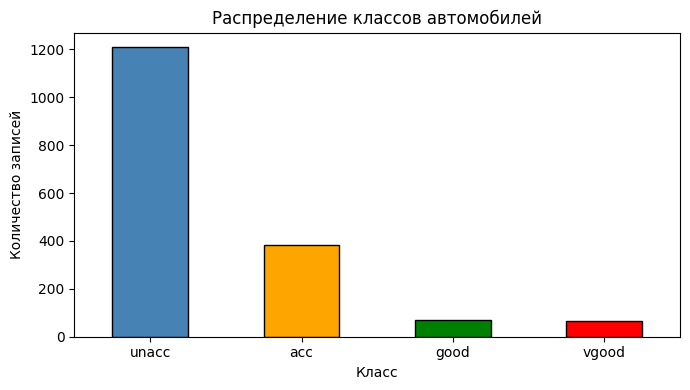

In [25]:
plt.figure(figsize=(7, 4))
data['class'].value_counts().plot(
    kind='bar', color=['steelblue', 'orange', 'green', 'red'], edgecolor='black'
)
plt.title('Распределение классов автомобилей')
plt.xlabel('Класс')
plt.ylabel('Количество записей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Из графика видно, что датасет несбалансированный: класс `unacc` значительно преобладает над остальными, а классы `good` и `vgood` представлены в значительно меньшем количестве. Это стоит учитывать при анализе результатов.

Далее строится тепловая карта корреляций для оценки зависимостей между признаками.

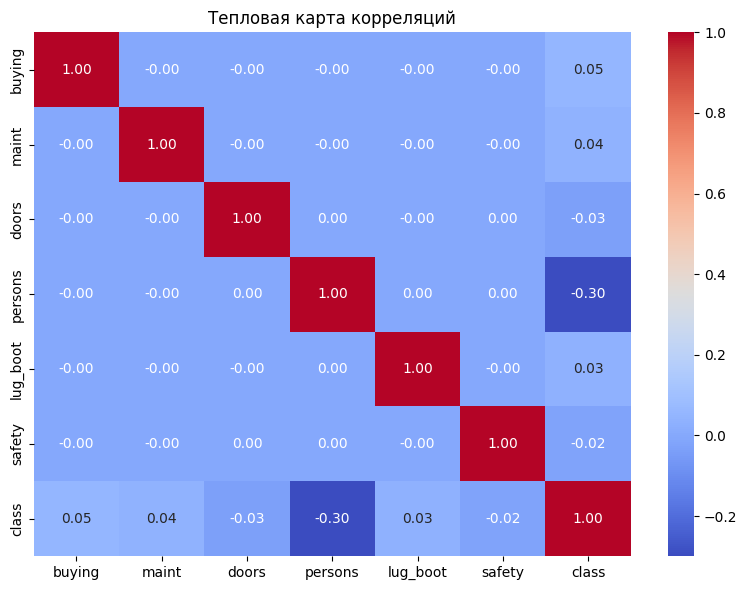

In [ ]:
data_temp = data.copy()
for col in data_temp.columns:
    data_temp[col] = LabelEncoder().fit_transform(data_temp[col])

plt.figure(figsize=(8, 6))
sns.heatmap(data_temp.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

Из тепловой карты видно, что признак `safety` имеет наибольшую положительную корреляцию с целевым классом. Признаки `buying` и `maint` имеют умеренную отрицательную корреляцию — чем дороже автомобиль, тем ниже его оценка.

Все признаки в датасете являются категориальными. Нейронные сети работают с числовыми данными, поэтому необходимо преобразовать категориальные признаки в числовые с помощью `LabelEncoder`. Затем выполняется нормализация с помощью `StandardScaler` — приводим все признаки к единому масштабу, что помогает сети быстрее и стабильнее обучаться.

In [27]:
data_encoded = data.copy()
label_encoders = {}

for col in data_encoded.columns:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

data_encoded.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [32]:
X = data_encoded.drop(columns=['class']).values.astype('float32')
y = data_encoded['class'].values.astype('int64')

scaler = StandardScaler()
X = scaler.fit_transform(X)

NUM_CLASSES = len(np.unique(y))
class_names = label_encoders['class'].classes_

Далее данные разбиваются на тренировочную (80%) и тестовую (20%) выборки с помощью `train_test_split`. Параметр `stratify=y` гарантирует, что соотношение классов сохраняется в обеих выборках.

После разделения данные преобразуются в тензоры PyTorch — формат, с которым работает нейронная сеть.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print(f'Обучающая выборка: {X_train_t.shape[0]} записей')
print(f'Тестовая выборка:  {X_test_t.shape[0]} записей')

Обучающая выборка: 1382 записей
Тестовая выборка:  346 записей


## 4. Построение модели нейронной сети

Была создана нейронная сеть прямого распространения (FNN) с помощью nn.Sequential. Архитектура включает входной слой, принимающий 6 нормализованных признаков, первый скрытый слой Linear(6 - 64) с функцией активации ReLU, второй скрытый слой Linear(64 - 32) с ReLU и выходной слой Linear(32 - 4) для четырех классов. Функция ReLU вводит нелинейность и помогает избежать затухания градиентов.

In [28]:
INPUT_SIZE = X_train_t.shape[1]

model = nn.Sequential(
    nn.Linear(INPUT_SIZE, 64), 
    nn.ReLU(),
    nn.Linear(64, 32),         
    nn.ReLU(),
    nn.Linear(32, NUM_CLASSES) 
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nКоличество параметров: {total_params}')

Sequential(
  (0): Linear(in_features=6, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=4, bias=True)
)

Количество параметров: 2660



## 6. Обучение модели

Перед обучением задаются фиксированные гиперпараметры, которые будут одинаковыми для всех оптимизаторов в дополнительном исследовании. Выбран оптимизатор **Adam**, функция потерь — `CrossEntropyLoss` (используется для многоклассовой классификации), метрика — `accuracy`.

Процесс обучения за одну эпоху: берётся батч данных → модель делает предсказания → вычисляется ошибка → ошибка распространяется обратно → веса обновляются. После каждой эпохи модель проверяется на тестовой выборке.

In [30]:
LEARNING_RATE = 0.001
BATCH_SIZE    = 32
EPOCHS        = 100

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, correct = 0.0, 0

    for i in range(0, len(X_train_t), BATCH_SIZE):
        X_batch = X_train_t[i:i+BATCH_SIZE]
        y_batch = y_train_t[i:i+BATCH_SIZE]

        optimizer.zero_grad()        
        outputs = model(X_batch)          
        loss = criterion(outputs, y_batch)  
        loss.backward()                    
        optimizer.step()                  
        epoch_loss += loss.item() * len(X_batch)
        correct    += (outputs.argmax(1) == y_batch).sum().item()

    train_losses.append(epoch_loss / len(X_train_t))
    train_accs.append(correct / len(X_train_t))

    model.eval()
    with torch.no_grad():
        val_out  = model(X_test_t)
        val_loss = criterion(val_out, y_test_t).item()
        val_acc  = (val_out.argmax(1) == y_test_t).float().mean().item()

    val_losses.append(val_loss)
    val_accs.append(val_acc)

print(f'Точность на тестовых данных: {val_accs[-1]:.4f}')

Точность на тестовых данных: 0.9971


## 7. Оценка модели

Строим графики изменения точности и функции потерь в зависимости от эпохи. Это позволяет визуально оценить процесс обучения и выявить возможные признаки переобучения.

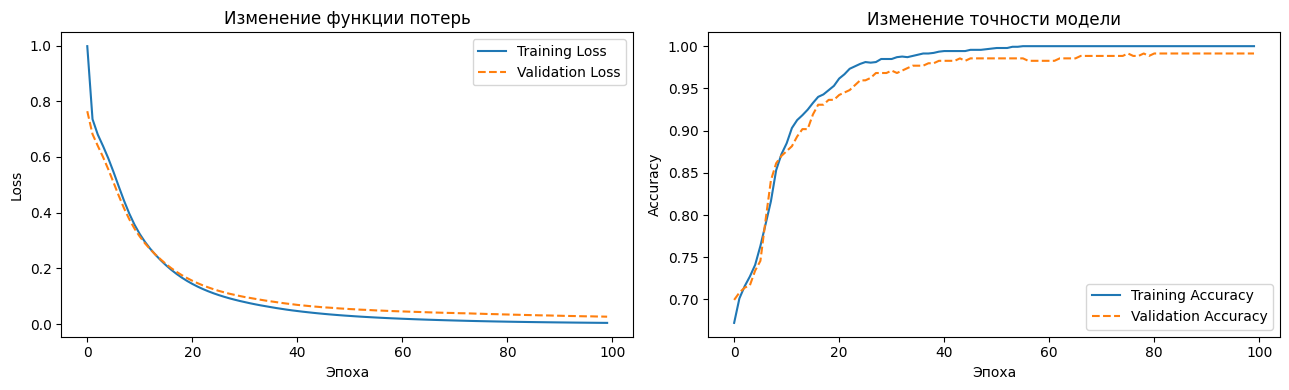

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, label='Training Loss')
axes[0].plot(val_losses,   label='Validation Loss', linestyle='--')
axes[0].set_title('Изменение функции потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Training Accuracy')
axes[1].plot(val_accs,   label='Validation Accuracy', linestyle='--')
axes[1].set_title('Изменение точности модели')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Дополнительное исследование: сравнение оптимизаторов AdamW, Adam, Adagrad

Было проведено сравнение трёх оптимизаторов: AdamW, Adam и Adagrad при фиксированных параметрах (lr=0.001, batch_size=32, epochs=100). Для каждого оптимизатора создавалась новая модель с одинаковой архитектурой. Adam -- адаптивный оптимизатор, использующий скользящие средние градиентов. AdamW -- модификация Adam с явной регуляризацией весов для снижения переобучения. Adagrad накапливает квадраты градиентов, что приводит к постепенному уменьшению шага обучения.

In [ ]:
def train_model(optimizer_name):
    torch.manual_seed(42)

    model = nn.Sequential(
        nn.Linear(INPUT_SIZE, 64), nn.ReLU(),
        nn.Linear(64, 32),         nn.ReLU(),
        nn.Linear(32, NUM_CLASSES)
    )

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    elif optimizer_name == 'Adagrad':
        optimizer = optim.Adagrad(model.parameters(), lr=LEARNING_RATE)

    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss, correct = 0.0, 0

        for i in range(0, len(X_train_t), BATCH_SIZE):
            X_batch = X_train_t[i:i+BATCH_SIZE]
            y_batch = y_train_t[i:i+BATCH_SIZE]

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(X_batch)
            correct    += (outputs.argmax(1) == y_batch).sum().item()

        train_losses.append(epoch_loss / len(X_train_t))
        train_accs.append(correct / len(X_train_t))

        model.eval()
        with torch.no_grad():
            val_out  = model(X_test_t)
            val_losses.append(criterion(val_out, y_test_t).item())
            val_accs.append((val_out.argmax(1) == y_test_t).float().mean().item())

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).argmax(1).numpy()

    final_acc = accuracy_score(y_test, y_pred)
    print(f'[{optimizer_name}] Точность: {final_acc:.4f} | Потери: {val_losses[-1]:.4f}')

    return {
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs':   train_accs,   'val_accs':   val_accs,
        'final_acc':    final_acc,    'preds':      y_pred
    }


print(f'Фиксированные параметры: lr={LEARNING_RATE}, batch_size={BATCH_SIZE}, epochs={EPOCHS}')
print('-' * 55)

results = {}
for opt_name in ['AdamW', 'Adam', 'Adagrad']:
    results[opt_name] = train_model(opt_name)

Фиксированные параметры: lr=0.001, batch_size=32, epochs=100
-------------------------------------------------------
[AdamW] Точность: 0.9913 | Потери: 0.0261
[Adam] Точность: 0.9913 | Потери: 0.0265
[Adagrad] Точность: 0.7139 | Потери: 0.6225


Далее строятся сравнительные графики изменения функции потерь и точности на валидационной и обучающей выборках для всех трёх оптимизаторов.

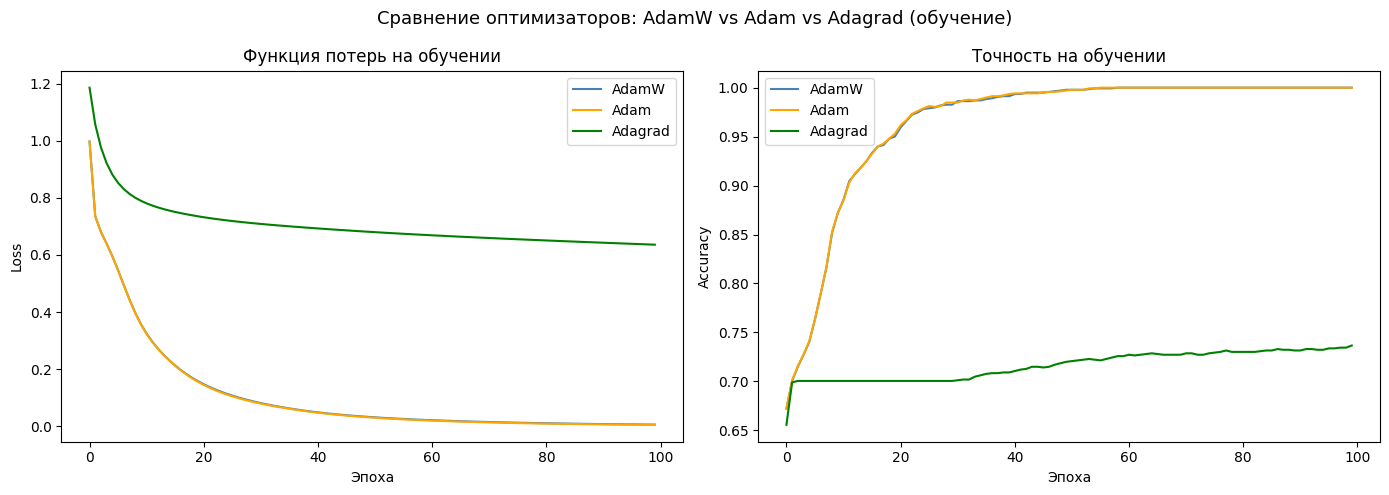

In [31]:
colors = {'AdamW': 'steelblue', 'Adam': 'orange', 'Adagrad': 'green'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for opt_name, res in results.items():
    axes[0].plot(res['train_losses'], label=opt_name, color=colors[opt_name])
    axes[1].plot(res['train_accs'],   label=opt_name, color=colors[opt_name])

axes[0].set_title('Функция потерь на обучении')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[1].set_title('Точность на обучении')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Сравнение оптимизаторов: AdamW vs Adam vs Adagrad (обучение)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Выводы

В ходе лабораторной работы была реализована и обучена нейронная сеть прямого распространения для классификации автомобилей на основе датасета Car Evaluation с использованием PyTorch.

Данные были разделены на обучающую (80%, 1382 записи) и тестовую (20%, 346 записей) выборки с сохранением пропорций классов. Архитектура модели включала два скрытых слоя с активацией ReLU и выходной слой на 4 класса.

Базовая модель с оптимизатором Adam достигла точности 99.71% на тестовой выборке. Анализ графиков показал быструю сходимость в первые 20 эпох и стабилизацию без признаков переобучения. В рамках дополнительного исследования были сравнены три оптимизатора: Adam и AdamW показали точность ~99.1%, Adagrad — только 71.4%. Низкая эффективность Adagrad была связана с чрезмерным уменьшением скорости обучения.

Таким образом, для данной задачи оптимизаторы Adam и AdamW являлись предпочтительными. AdamW рекомендовался при необходимости защиты от переобучения. Adagrad не подходил из-за агрессивного снижения скорости обучения. 